In [1]:
import matplotlib.pyplot as plt
from pycellga.GraphProblem import GraphRastriginProblem, GraphRosenbrockProblem
from pycellga.mutation.byte_mutation_random import ByteMutationRandom
from pycellga.recombination.byte_one_point_crossover import ByteOnePointCrossover
from pycellga.selection.tournament_selection import TournamentSelection
from pycellga.optimizer import graph_cga
from pycellga.utils import set_up_problem, PROBLEM_TYPING
import numpy as np
import cma
import networkx as nx

from pyswarms.single.global_best import GlobalBestPSO
from scipy.optimize import differential_evolution

from pycellga.GraphProblem import GraphAckleyProblem, GraphGriewankProblem

import pandas as pd
import seaborn as sns

def set_up_problem(n_rows, n_cols, dims, offset, problem_type: PROBLEM_TYPING, boundaries: int = 5, graph_type: str="torus", **kwargs)-> PROBLEM_TYPING:

    n_nodes = n_rows * n_cols

    if graph_type == "torus":
        grid = nx.grid_graph(dim=(n_rows, n_cols), periodic=True)
        node_map = {node: i for i, node in enumerate(grid.nodes)}
        graph = nx.Graph()
        for edge in grid.edges:
            graph.add_edge(node_map[edge[0]], node_map[edge[1]])
    elif graph_type == "erdos_renyi":
        graph = nx.erdos_renyi_graph(n=n_nodes, **kwargs)
    elif graph_type == "watts_strogatz":
        graph = nx.watts_strogatz_graph(n=n_nodes, **kwargs)
    elif graph_type == "barabasi_albert":
        graph = nx.barabasi_albert_graph(n=n_nodes, **kwargs )
    else:
        raise ValueError(f"Unknown graph_type: {graph_type}")

    return problem_type(n_var=dims, graph=graph, offset=offset, boundaries=boundaries)

def run_cga(dims, n_generations, n_rows, n_cols, problem):
    result = graph_cga(
        n_rows=n_rows,
        n_cols=n_cols,
        n_gen=n_generations,
        ch_size=dims,
        p_crossover=0.9,
        p_mutation=0.2,
        problem=problem,
        selection=TournamentSelection,
        recombination=ByteOnePointCrossover,
        mutation=ByteMutationRandom,
        seed_par=100,

    )
    return (result.chromosome, result.fitness_value, result.fitness_history)



def run_cma(problem, dims, max_evals, boundaries, generation_size=20):
    x0 = np.random.random(dims)
    sigma = 0.5
    fitness_history = []

    best_so_far = float('inf')
    es = cma.CMAEvolutionStrategy(
        x0,
        sigma,
        {
            'maxfeval': max_evals,
            'popsize': generation_size,
            'verb_disp': 0,
            'bounds': [[-boundaries] * dims, [boundaries] * dims],
        }
    )
    eval_count = 0
    while not es.stop() and eval_count < max_evals:
        solutions = es.ask()
        function_values = [problem.f(x) for x in solutions]

        for val in function_values:
            if val < best_so_far:
                best_so_far = val
            fitness_history.append(best_so_far)

        eval_count += len(function_values)
        es.tell(solutions, function_values)

    return (es.result.xbest, es.result.fbest, fitness_history)


def run_pso(problem, dims, max_evals, boundaries, generation_size=30):
    options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

    bounds = (np.full(dims, -boundaries), np.full(dims, boundaries))

    def objective_function(X):
        return np.array([problem.f(x) for x in X])

    optimizer = GlobalBestPSO(
        n_particles=generation_size,
        dimensions=dims,
        options=options,
        bounds=bounds
    )

    iters = max_evals // generation_size
    best_cost, best_pos = optimizer.optimize(objective_function, iters=iters)

    fitness_history = []
    for cost in optimizer.cost_history:
        fitness_history.extend([cost] * generation_size)

    return (best_pos, best_cost, fitness_history)

def run_differential_evolution(problem, dims, max_evals, boundaries, generation_size=15):
    bounds = [(-boundaries, boundaries) for _ in range(dims)]

    eval_count = 0
    best_fitness_so_far = float('inf')
    fitness_history = []

    def objective_with_tracking(x):
        nonlocal eval_count, best_fitness_so_far, fitness_history

        eval_count += 1
        if eval_count > max_evals:
            return float('inf')

        fitness = problem.f(x)

        if fitness < best_fitness_so_far:
            best_fitness_so_far = fitness

        fitness_history.append(best_fitness_so_far)

        return fitness

    fitness_history = []

    result = differential_evolution(
        objective_with_tracking,
        bounds=bounds,
        popsize=generation_size,
        maxiter=max_evals // generation_size,
        seed=42,
        disp=False,
    )

    return result.x, result.fun, fitness_history

In [20]:
def study_erdos_renyi(p_values, problem_classes, dims, n_generations, repetitions=5, n_rows=5, n_cols=5, boundaries=5, **kwargs):
    results = {}
    for problem_class in problem_classes:
        class_results = {}
        for p in p_values:
            fitness_values = []
            for _ in range(repetitions):
                problem = set_up_problem(
                    n_rows=n_rows, n_cols=n_cols, dims=dims,
                    offset=np.random.rand() * np.random.randint(1, boundaries) * (-1) ** np.random.randint(0, 2),
                    problem_type=problem_class,
                    boundaries=boundaries,
                    graph_type="erdos_renyi",
                    p=p
                )
                _, fitness_value, _ = run_cga(
                    problem=problem, dims=dims,
                    n_generations=n_generations,
                    n_rows=n_rows, n_cols=n_cols
                )
                fitness_values.append(fitness_value)
            class_results[f"p={p}"] = fitness_values
        results[problem_class.__name__] = class_results
    return results

def study_watts_strogatz(k_values, p_values, problem_classes, dims, n_generations, repetitions=5, n_rows=5, n_cols=5, boundaries=5,**kwargs):
    results = {}
    for problem_class in problem_classes:
        class_results = {}
        for k in k_values:
            for p in p_values:
                fitness_values = []
                for _ in range(repetitions):
                    problem = set_up_problem(
                        n_rows=n_rows, n_cols=n_cols, dims=dims,
                        offset=np.random.rand() * np.random.randint(1, boundaries) * (-1) ** np.random.randint(0, 2),
                        problem_type=problem_class,
                        boundaries=boundaries,
                        graph_type="watts_strogatz",
                        k=k, p=p
                    )
                    _, fitness_value, _ = run_cga(
                        problem=problem, dims=dims,
                        n_generations=n_generations,
                        n_rows=n_rows, n_cols=n_cols
                    )
                    fitness_values.append(fitness_value)
                class_results[(k, p)] = fitness_values
        results[problem_class.__name__] = class_results
    return results

def study_barabasi_albert(m_values, problem_classes, dims, n_generations, repetitions=5, n_rows=5, n_cols=5, boundaries=5, **kwargs):
    results = {}
    for problem_class in problem_classes:
        class_results = {}
        for m in m_values:
            label = f"m={m}"
            fitness_values = []
            for _ in range(repetitions):
                problem = set_up_problem(
                    n_rows=n_rows, n_cols=n_cols, dims=dims,
                    offset=np.random.rand() * np.random.randint(1, boundaries) * (-1) ** np.random.randint(0, 2),
                    problem_type=problem_class,
                    boundaries=boundaries,
                    graph_type="barabasi_albert",
                    m=m
                )
                _, fitness_value, _ = run_cga(
                    problem=problem, dims=dims,
                    n_generations=n_generations,
                    n_rows=n_rows, n_cols=n_cols
                )
                fitness_values.append(fitness_value)
            class_results[label] = fitness_values
        results[problem_class.__name__] = class_results
    return results

def plot_param_bar(results, title_prefix):
    for problem_name, result_dict in results.items():
        keys = list(result_dict.keys())
        means = [np.mean(result_dict[k]) for k in keys]
        stds = [np.std(result_dict[k]) for k in keys]

        plt.figure(figsize=(10, 5))
        bars = plt.bar(keys, means, yerr=stds, capsize=5, color='skyblue')
        plt.ylabel("Fitness")
        plt.title(f"{title_prefix} - {problem_name}")
        plt.grid(axis='y')

        for bar, mean in zip(bars, means):
            plt.text(bar.get_x() + bar.get_width()/2.0, mean + 0.01, f"{mean:.2f}", ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

def plot_param_heatmap(results, title_prefix):
    for problem_name, result_dict in results.items():
        data = []
        for (k_val, p_val), value in result_dict.items():
            fitness_value = np.mean(value)
            data.append((k_val, p_val, fitness_value))

        df = pd.DataFrame(data, columns=['k', 'p', 'fitness'])
        pivot_df = df.pivot(index='p', columns='k', values='fitness')

        plt.figure(figsize=(16, 8))
        sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Fitness'})
        plt.title(f"{title_prefix} - {problem_name}")
        plt.xlabel("k")
        plt.ylabel("p")
        plt.tight_layout()
        plt.show()


config = {
    'dims': 50,
    'n_generations': 100,
    'n_rows': 5,
    'n_cols': 5,
    'boundaries': 5,
}

problem_classes = [
    GraphRastriginProblem,
    GraphRosenbrockProblem,
    GraphAckleyProblem,
    GraphGriewankProblem
]


erdos_results = study_erdos_renyi(p_values=[0.1, 0.3, 0.5, 0.7, 0.9], problem_classes=problem_classes, repetitions=10,  **config)

watts_results = study_watts_strogatz(k_values=list(range(2, config['n_rows']*config['n_cols'], 2)), p_values=[0.1, 0.3, 0.5, 0.7, 0.9], problem_classes=problem_classes, repetitions=10, **config)

barabasi_results = study_barabasi_albert(m_values=list(range(2, config['n_rows']*config['n_cols'], 2)), problem_classes=problem_classes, repetitions=10, **config)


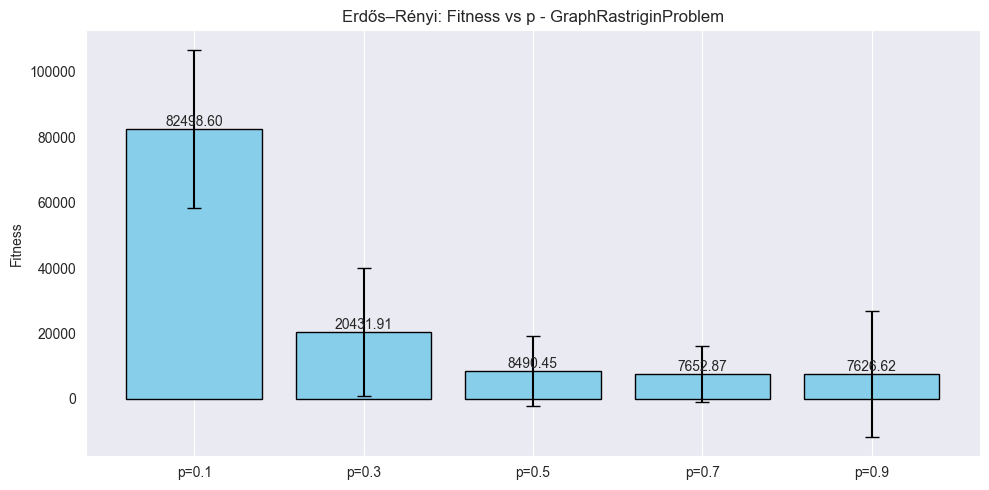

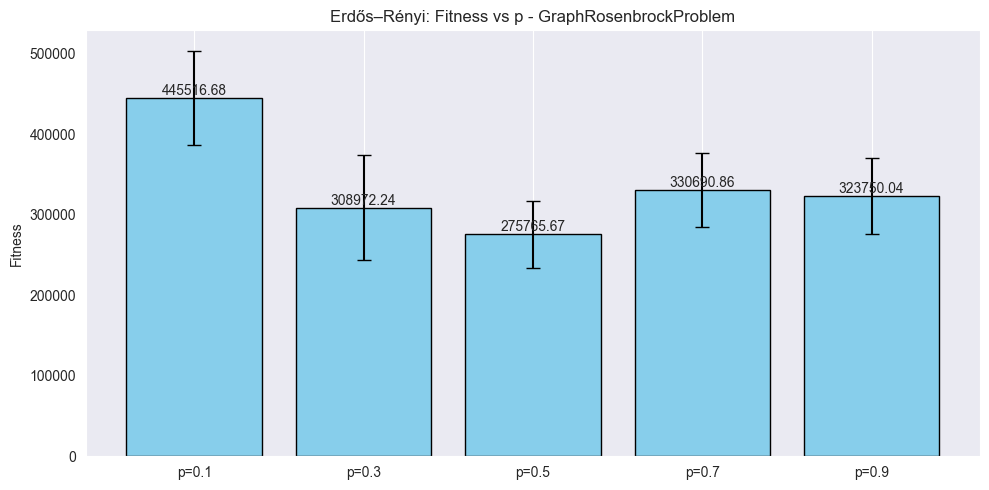

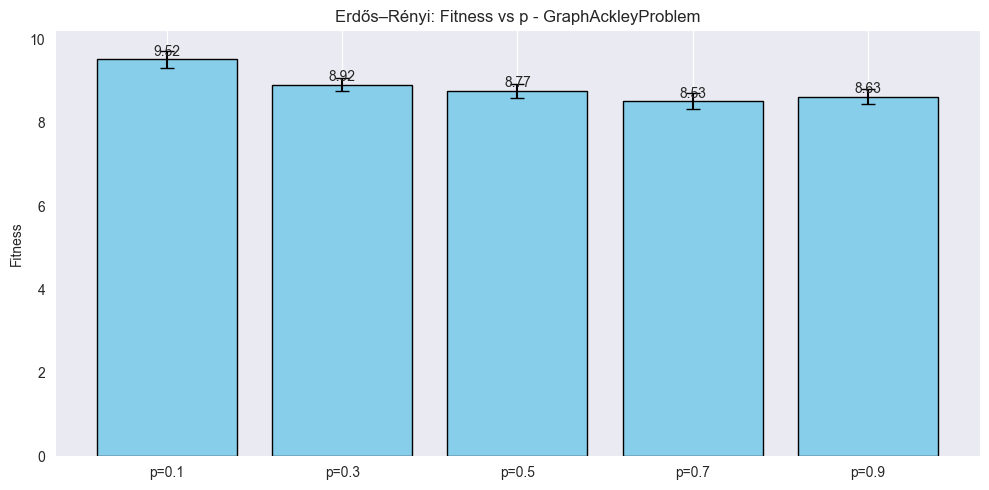

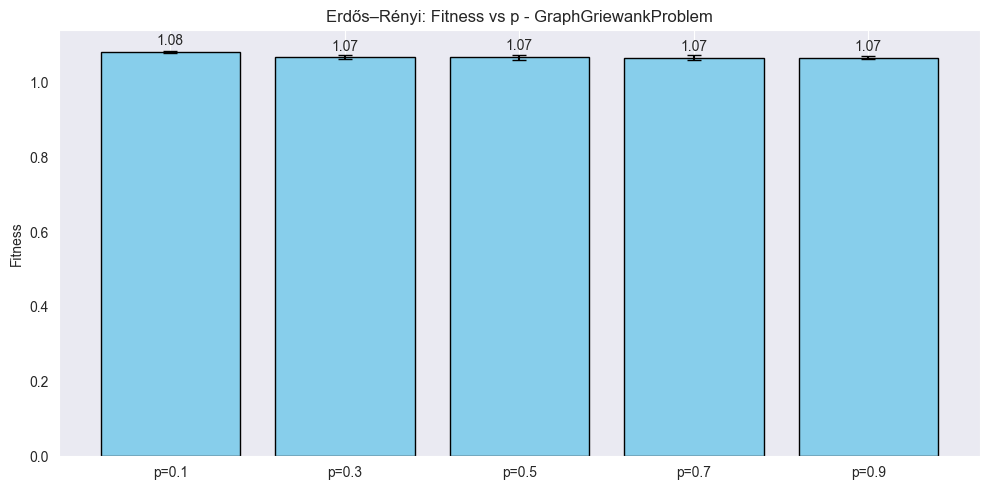

In [6]:
plot_param_bar(erdos_results, "Erdős–Rényi: Fitness vs p")

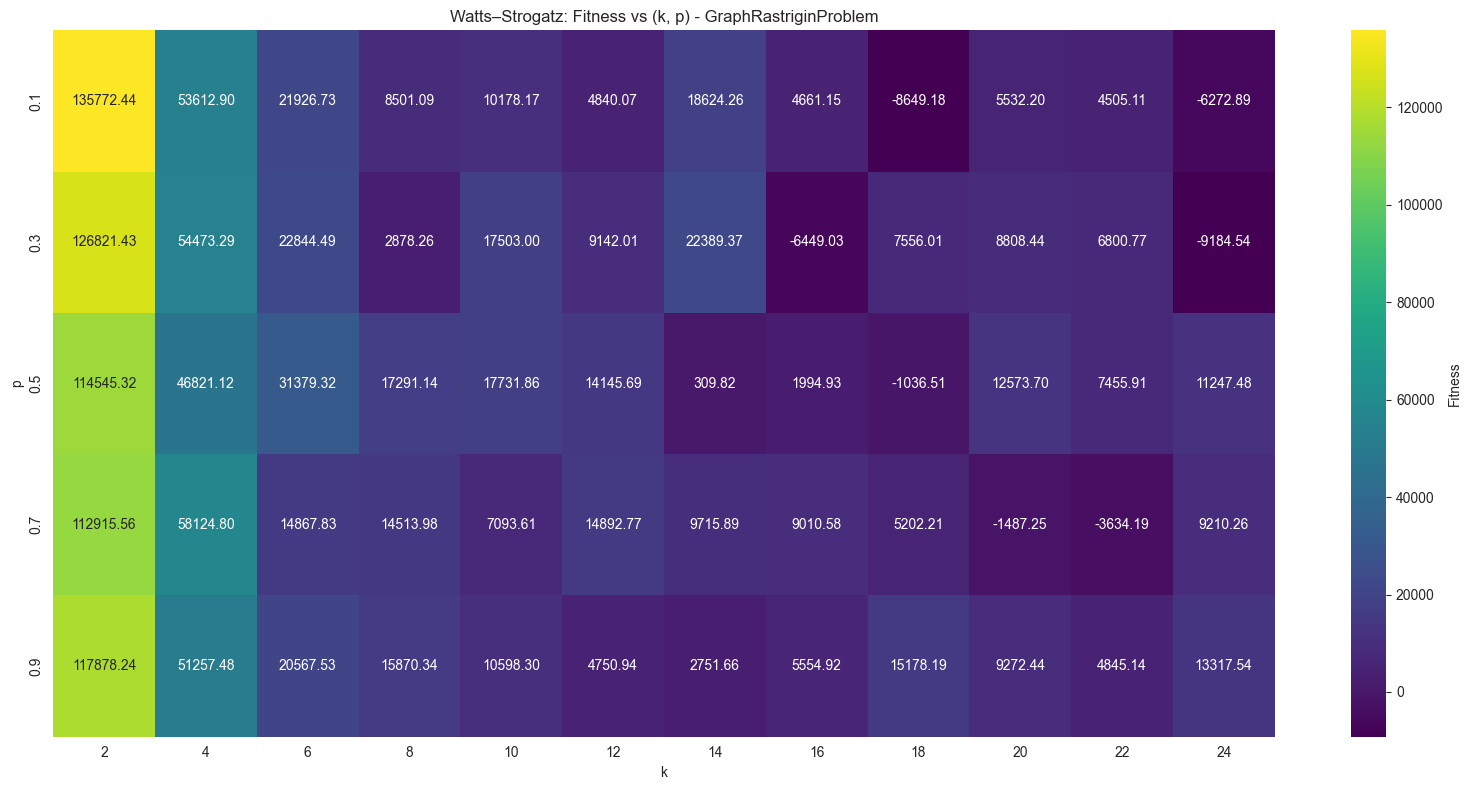

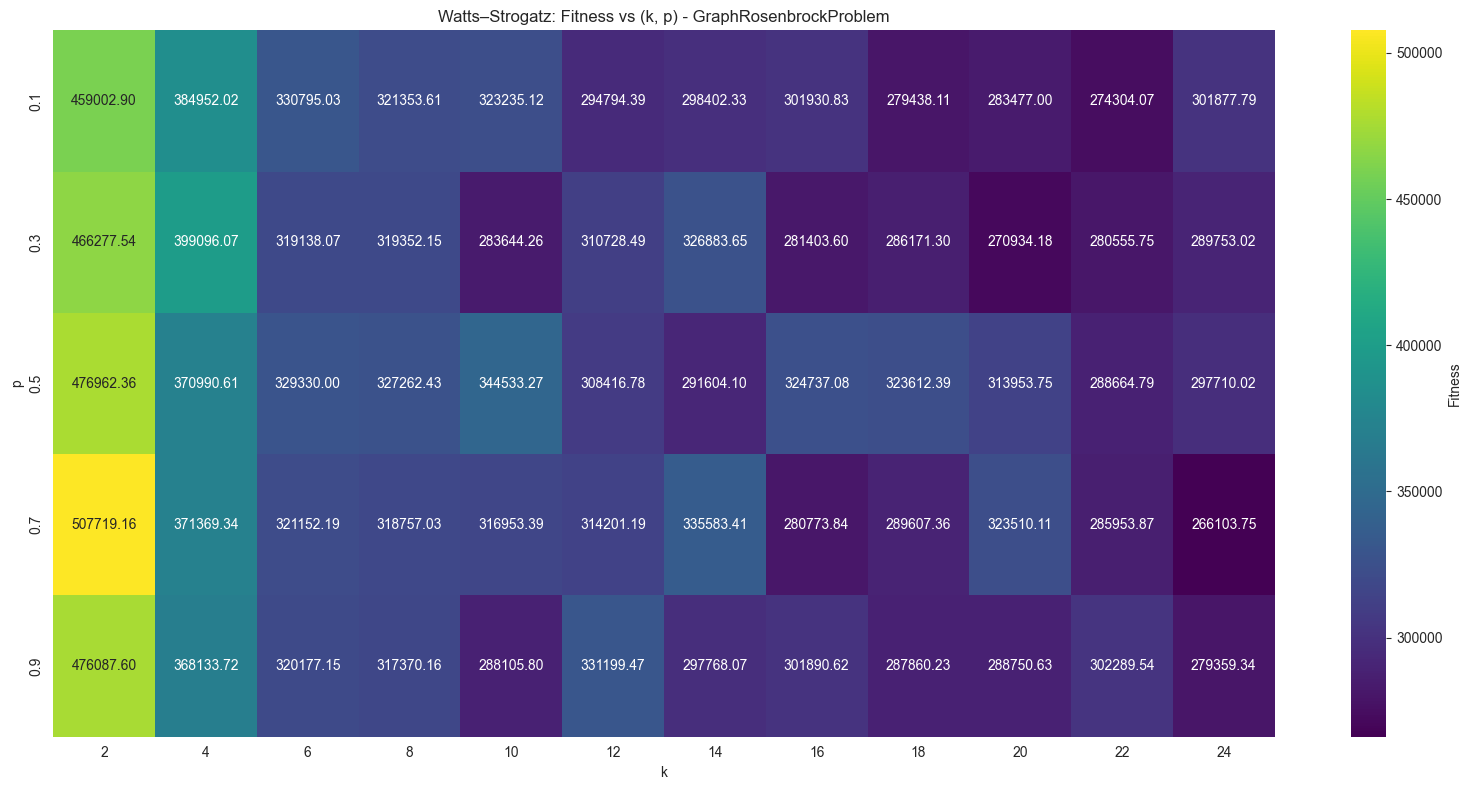

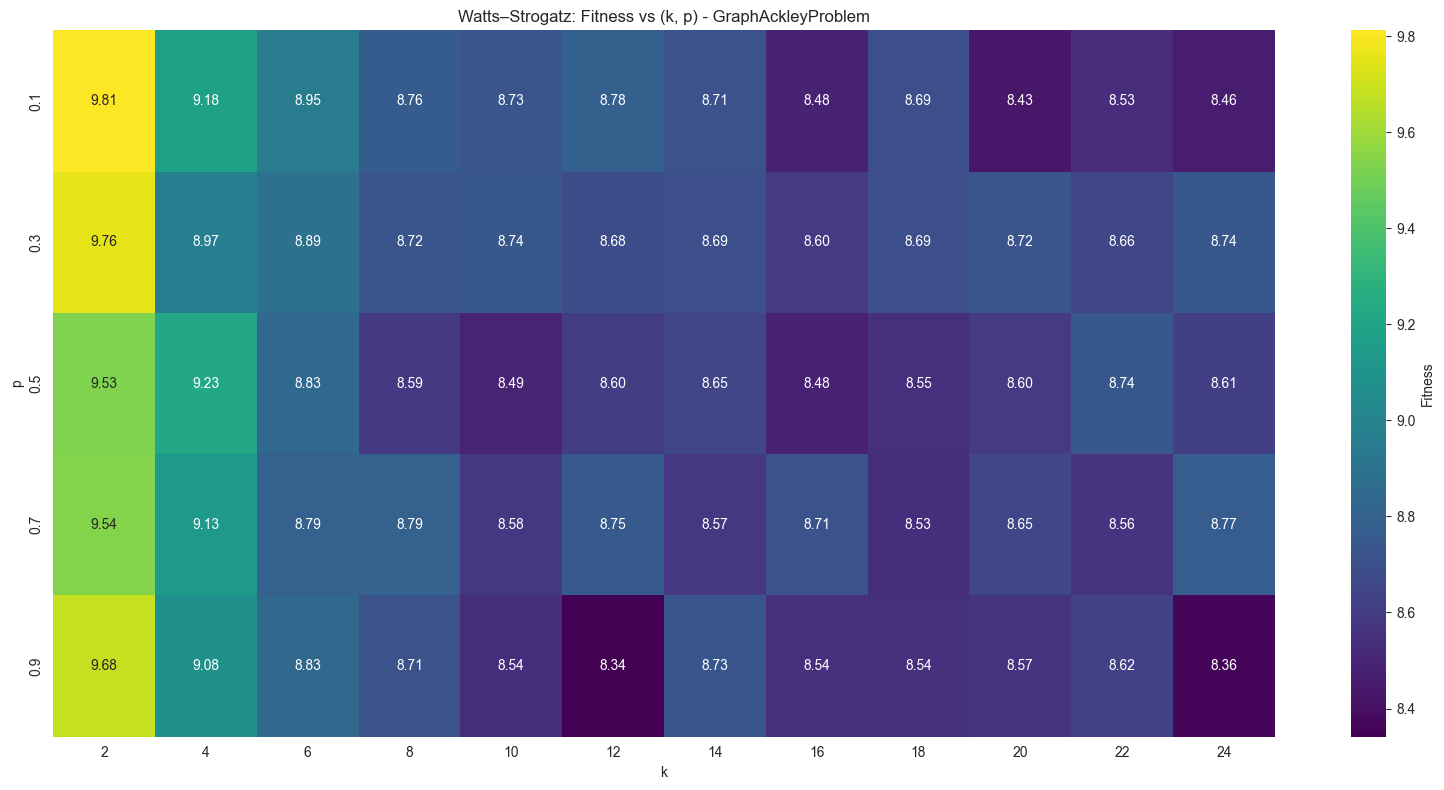

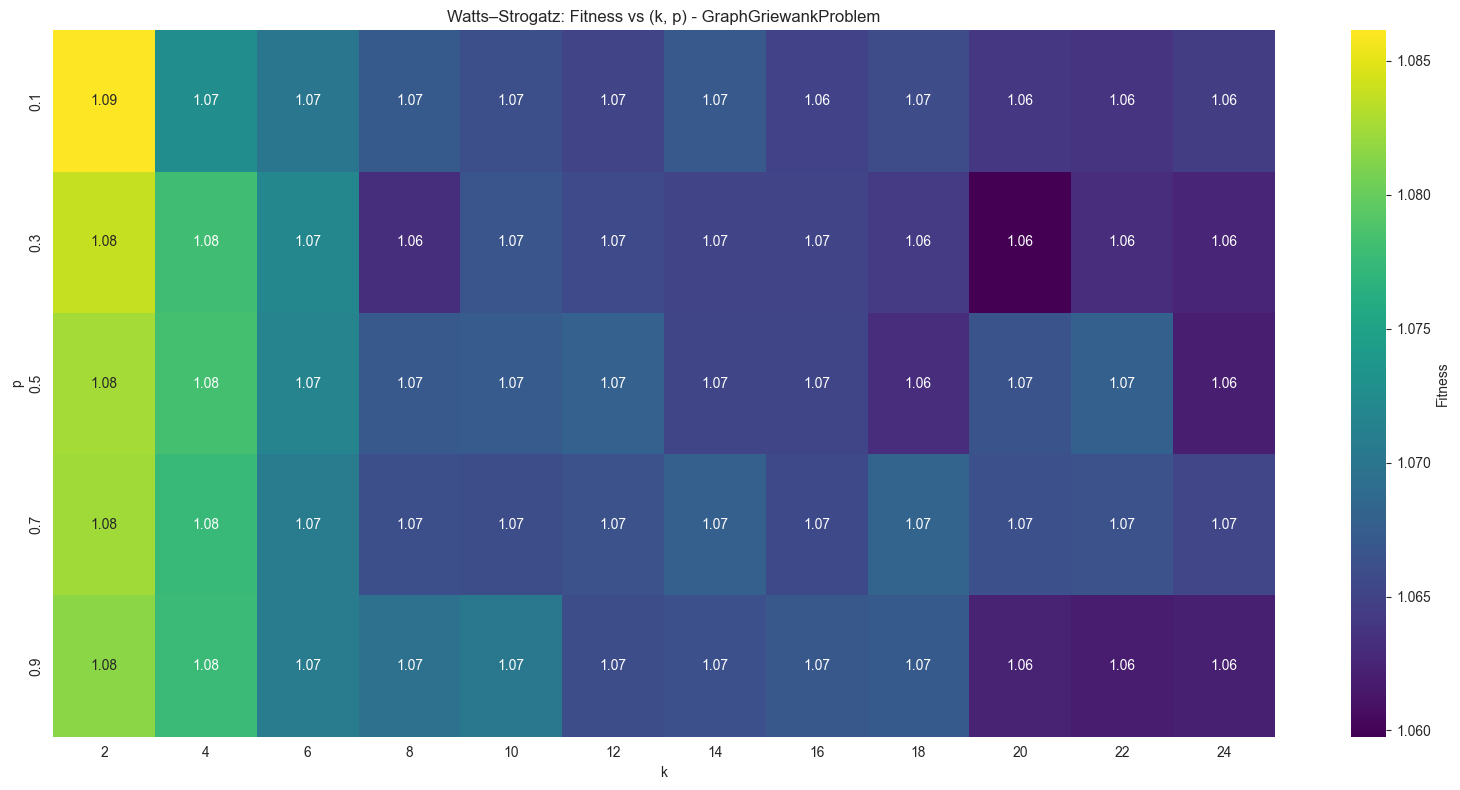

In [21]:
plot_param_heatmap(watts_results, "Watts–Strogatz: Fitness vs (k, p)")

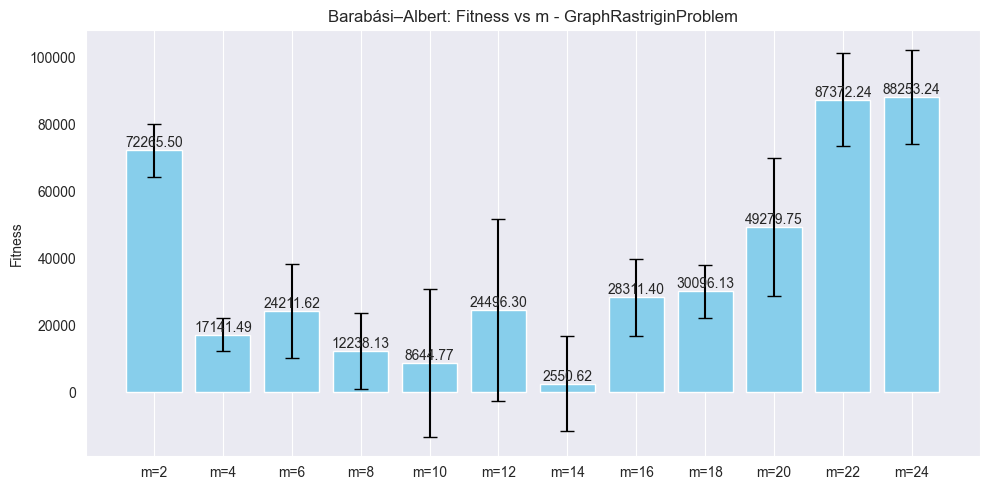

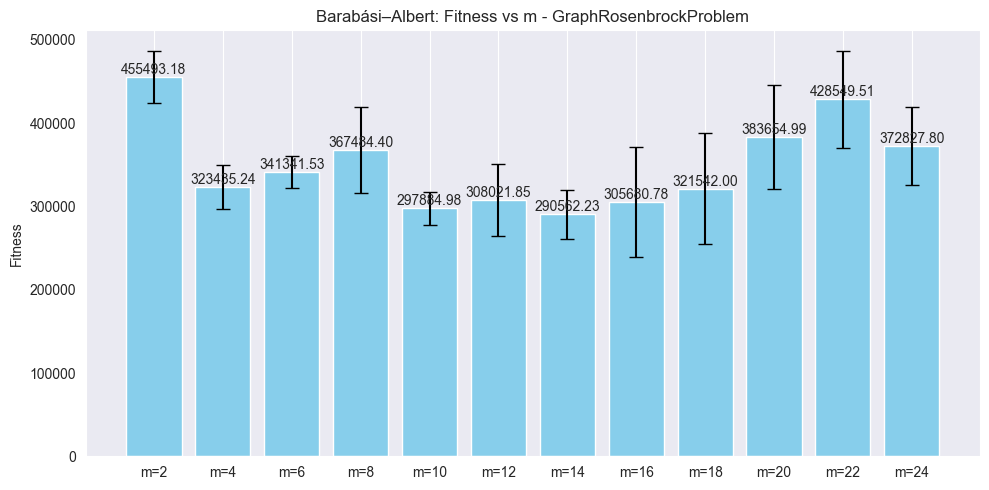

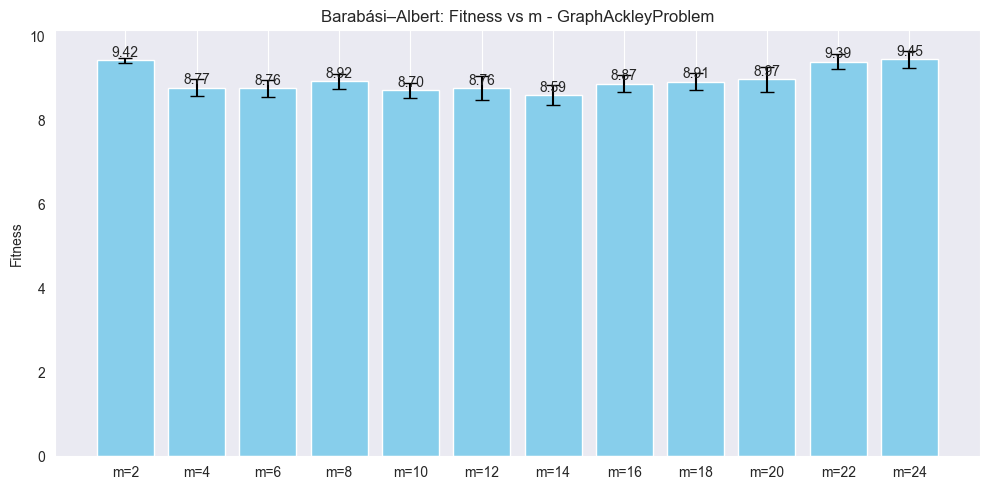

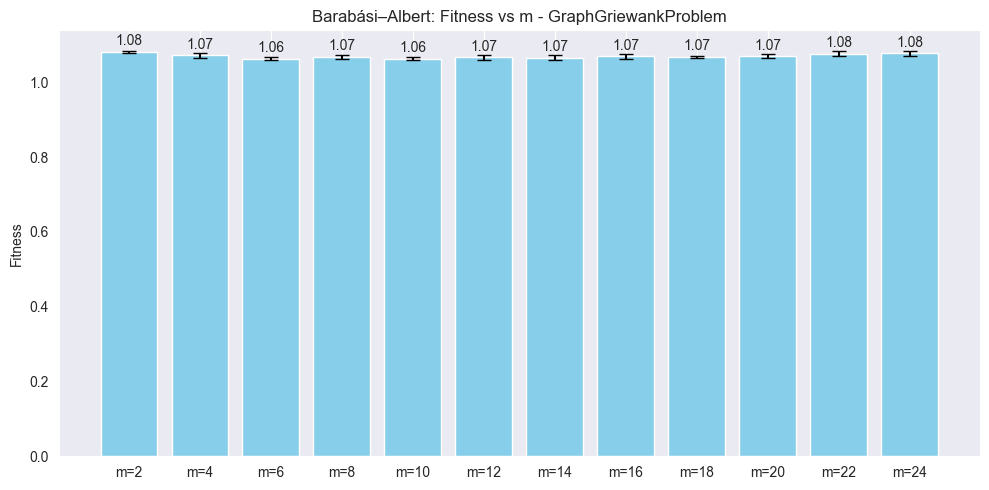

In [11]:
plot_param_bar(barabasi_results, "Barabási–Albert: Fitness vs m")

In [2]:
def evaluate_method(method_func, problem_type, dims, max_evals, repetitions=10, use_cga=False, graph_type="torus",  n_rows=5, n_cols=5, boundaries=5, label=None, **kwargs):
    histories = []

    for _ in range(repetitions):
        problem = set_up_problem(
            n_rows=n_rows,
            n_cols=n_cols,
            dims=dims,
            offset=np.random.rand() * np.random.randint(1, boundaries) * (-1) ** np.random.randint(0, 2),
            problem_type=problem_type,
            boundaries=boundaries,
            graph_type=graph_type,
            **kwargs.get('graph_params', {})
        )

        if use_cga:
            result = method_func(
                dims=dims,
                n_generations=max_evals // (2*n_rows*n_cols),
                n_rows=n_rows,
                n_cols=n_cols,
                problem=problem
            )
        else:
            result = method_func(
                problem=problem,
                dims=dims,
                max_evals=max_evals,
                boundaries=boundaries
            )

        histories.append(np.array(result[2]))

    avg_history = np.mean(histories, axis=0)
    std_history = np.std(histories, axis=0)
    return avg_history, std_history

def plot_evaluation_histories(results, title, dims, show_std=False):
    plt.figure(figsize=(14, 7))

    def plot_fitness(avg, std, label, color, show_std=False):
        x = np.arange(len(avg))
        plt.plot(x, avg, label=label, color=color)
        if show_std:
            plt.fill_between(x, avg - std, avg + std, alpha=0.2, color=color)

    for label, (avg, std, color) in results.items():
        plot_fitness(avg, std, label, color, show_std)

    plt.title(f"{title} Problem Dims: {dims}")
    plt.xlabel("Evaluations")
    plt.ylabel("Fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_graph_comparison(problem_classes, graph_types, graphs_params, dims, max_evals, repetitions=10, n_rows=5, n_cols=5, boundaries=5, show_std=False):

    for problem_name, problem_cls in problem_classes.items():
        print(f"Running graph comparison: {problem_name}")
        results = {}

        for graph_type, color in graph_types.items():
            try:
                avg, std = evaluate_method(
                    run_cga,
                    problem_type=problem_cls,
                    use_cga=True,
                    graph_type=graph_type,
                    repetitions= repetitions,
                    n_rows=n_rows,
                    n_cols=n_cols,
                    dims=dims,
                    boundaries=boundaries,
                    max_evals=max_evals,
                    graph_params=graphs_params.get(graph_type, {}),
                )
                results[graph_type] = (avg, std, color)
            except Exception as e:
                print(f"Failed for {graph_type}: {e}")
                continue

        plot_evaluation_histories(results, f"Graph Comparison - {problem_name}", dims, show_std)

def run_size_comparison(problem_classes, grid_configs, graph_type, max_evals,  dims,repetitions=10, boundaries=5, graph_params={}, show_std=False):

    for problem_name, problem_cls in problem_classes.items():
        print(f"Running size comparison: {problem_name}")
        results = {}

        for (n_rows, n_cols), color in grid_configs.items():
            label = f"{n_rows}x{n_cols}"
            try:
                avg, std = evaluate_method(
                    run_cga,
                    problem_type=problem_cls,
                    use_cga=True,
                    graph_type=graph_type,
                    repetitions= repetitions,
                    n_rows=n_rows,
                    n_cols=n_cols,
                    dims=dims,
                    boundaries=boundaries,
                    max_evals=max_evals,
                    graph_params=graph_params
                )
                results[label] = (avg, std, color)
            except Exception as e:
                print(f"Failed for size {label}: {e}")
                continue

        plot_evaluation_histories(results, f"Size Comparison - {problem_name}", dims, show_std)


def run_method_comparison(problem_classes, methods, graph_type, dims, max_evals, repetitions=10, n_rows=5, n_cols=5, boundaries=5, graph_params={}, show_std=False):
    for problem_name, problem_cls in problem_classes.items():
        print(f"Running method comparison: {problem_name}")
        results = {}

        for label, (method, color) in methods.items():
            try:
                avg, std = evaluate_method(
                    method,
                    problem_type=problem_cls,
                    use_cga=(label == "CGA"),
                    graph_type=graph_type,
                    repetitions=repetitions,
                    n_rows=n_rows,
                    n_cols=n_cols,
                    dims=dims,
                    boundaries=boundaries,
                    max_evals=max_evals,
                    graph_params=graph_params
                )
                results[label] = (avg, std, color)
            except Exception as e:
                print(f"Failed for method {label}: {e}")
                continue

        plot_evaluation_histories(results, f"Method Comparison - {problem_name}", dims, show_std)


Running graph comparison: Rastrigin Problem


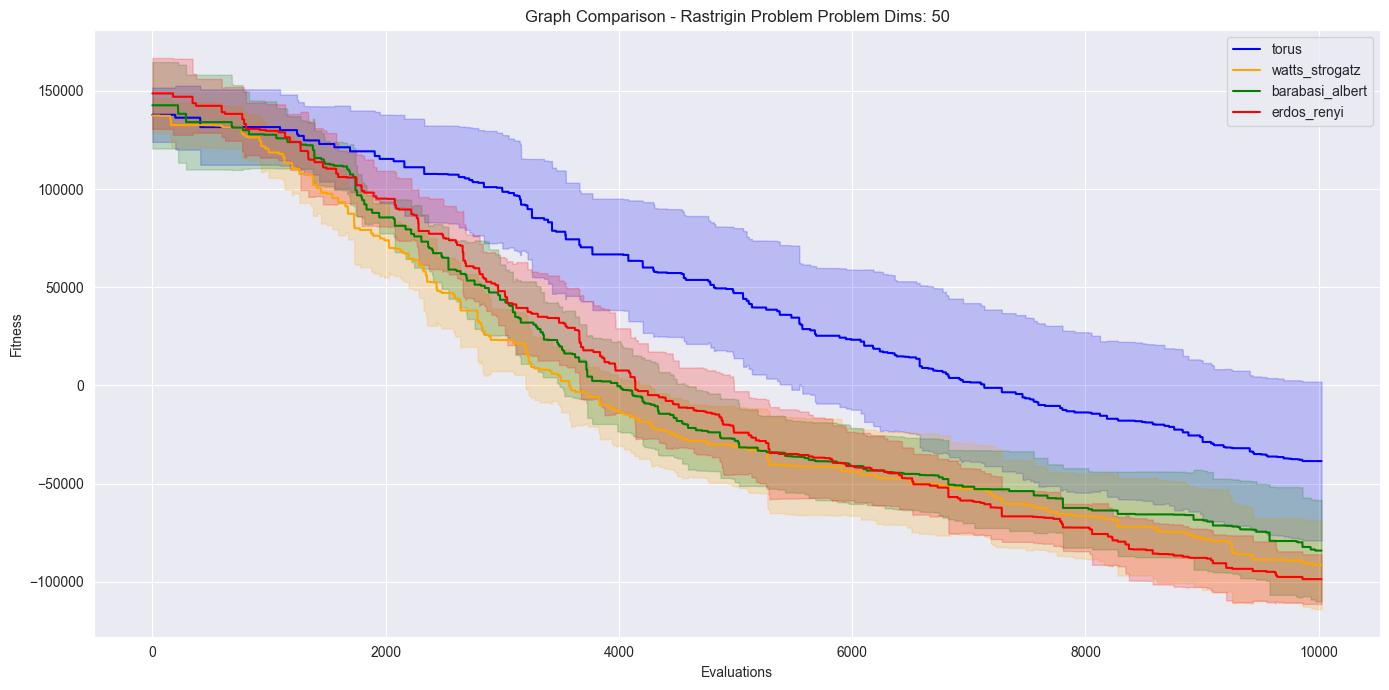

Running graph comparison: Rosenbrock Problem


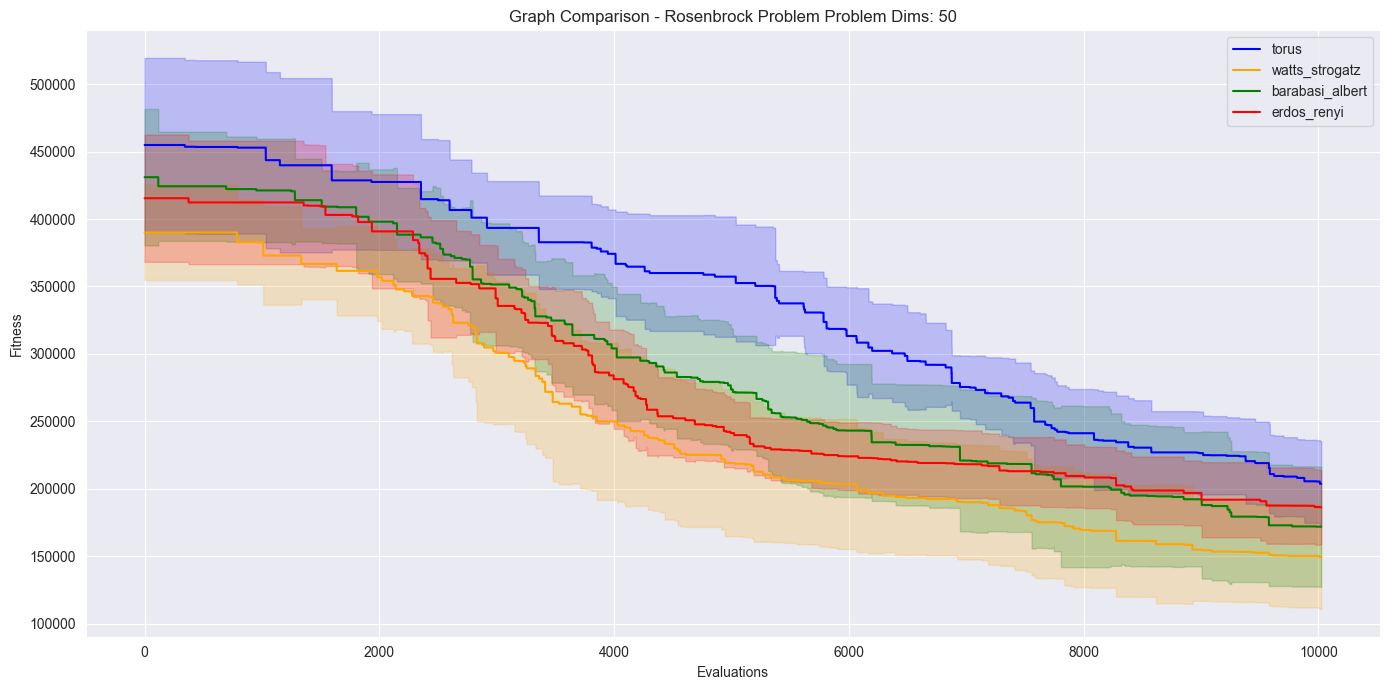

Running graph comparison: Ackley Problem


C:\Users\jakub\Desktop\Projects\UMISI\Sem_1\pycellga\pycellga\GraphProblem.py:86: RuntimeWarning: overflow encountered in scalar add
  sum1 = sum(gene ** 2 for gene in x)


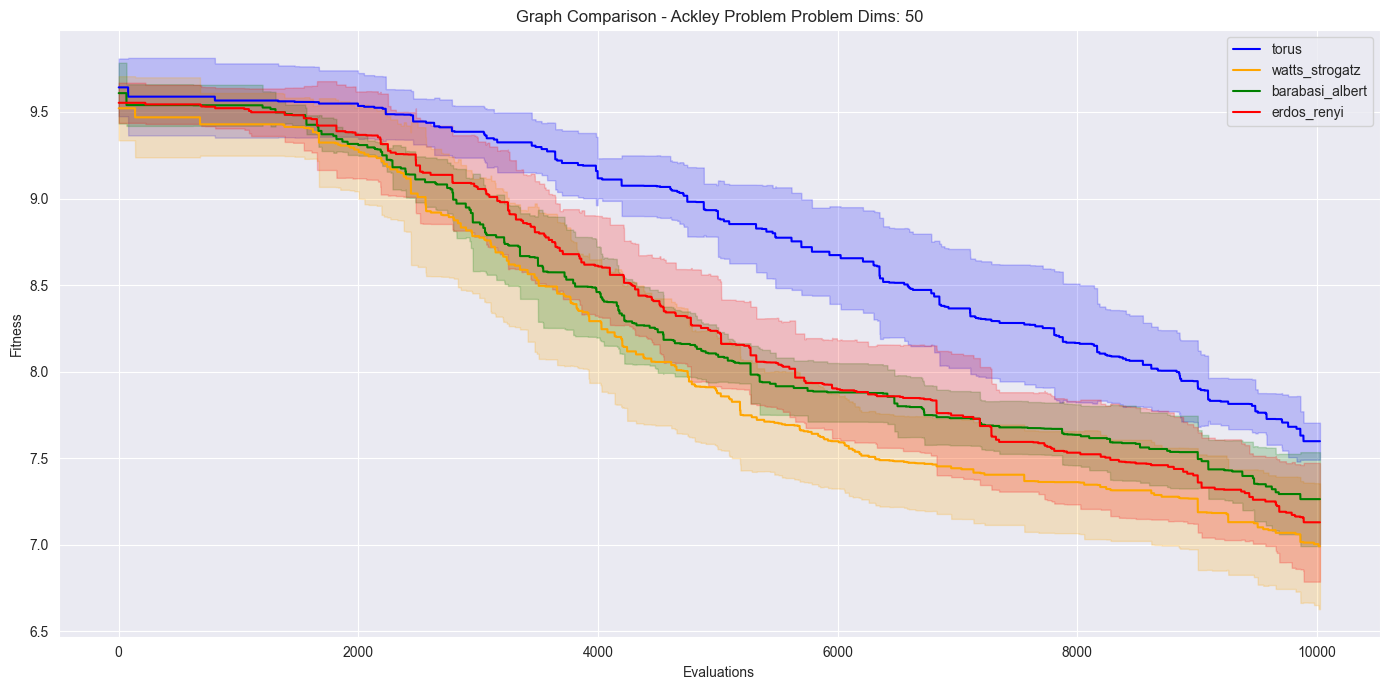

Running graph comparison: Griewank Problem


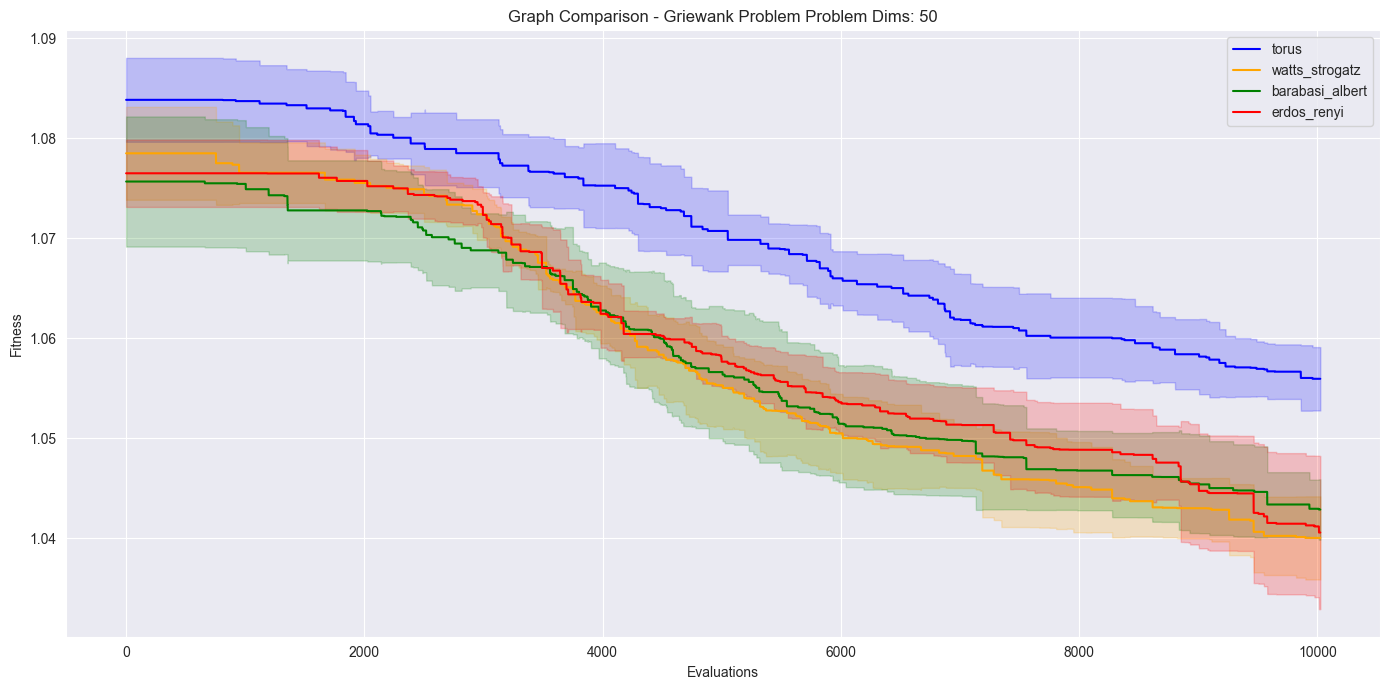

In [10]:

problem_classes = {
    "Rastrigin Problem": GraphRastriginProblem,
    "Rosenbrock Problem": GraphRosenbrockProblem,
    "Ackley Problem": GraphAckleyProblem,
    "Griewank Problem": GraphGriewankProblem,

}

graph_types = {
    "torus": "blue",
    "watts_strogatz": "orange",
    "barabasi_albert": "green",
    "erdos_renyi": "red"
}

graphs_params = {
    "watts_strogatz": {"k": 18, "p": 0.1},
    "barabasi_albert": {"m": 14},
    "erdos_renyi": {"p": 0.5}
}

config = {
    'n_rows': 5,
    'n_cols': 5,
    'boundaries': 5,
}

run_graph_comparison(problem_classes, graph_types, graphs_params, dims=50, max_evals=10000, repetitions=5, show_std=True, **config)


Running size comparison: Rastrigin Problem


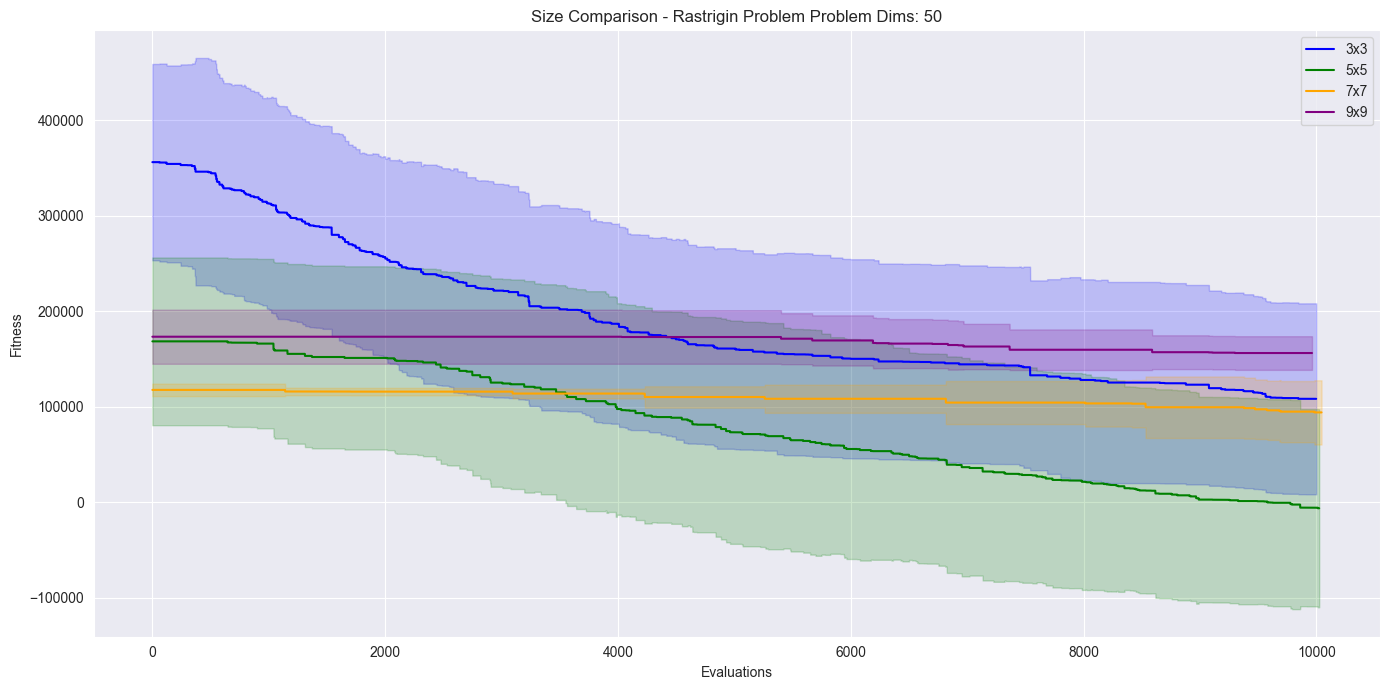

Running size comparison: Rosenbrock Problem


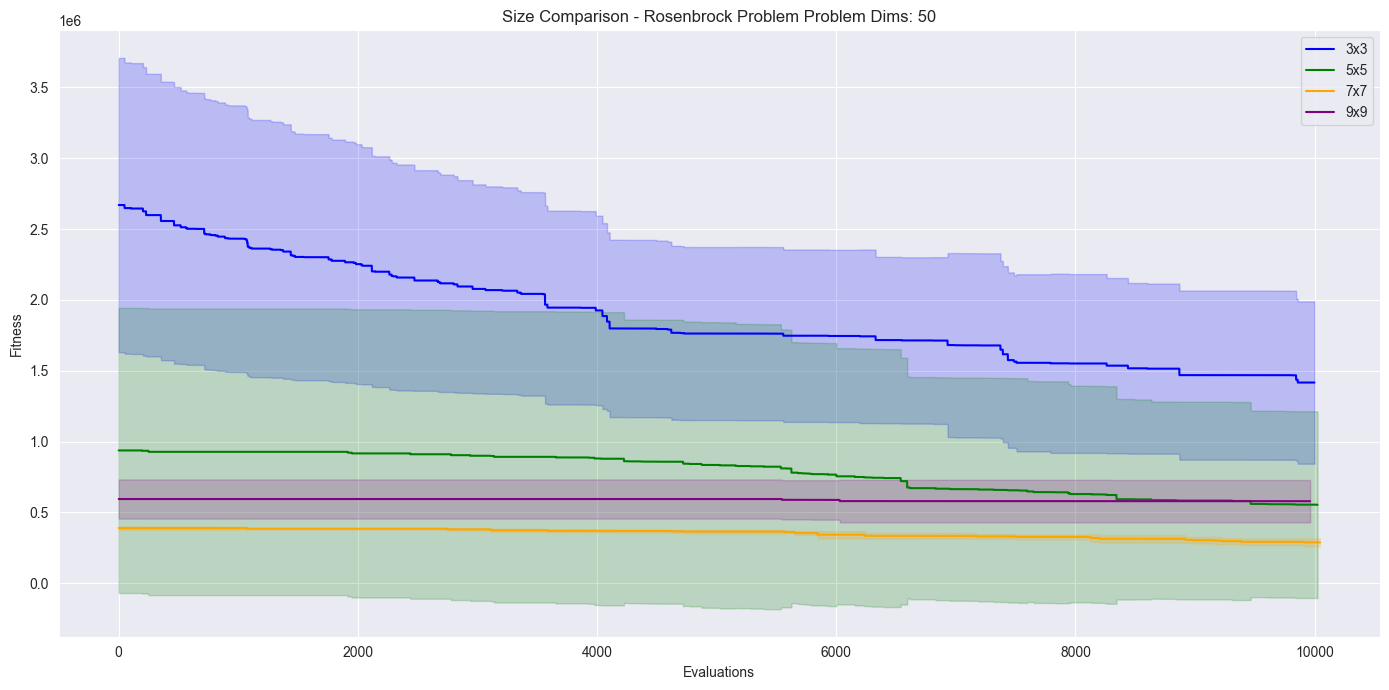

Running size comparison: Ackley Problem


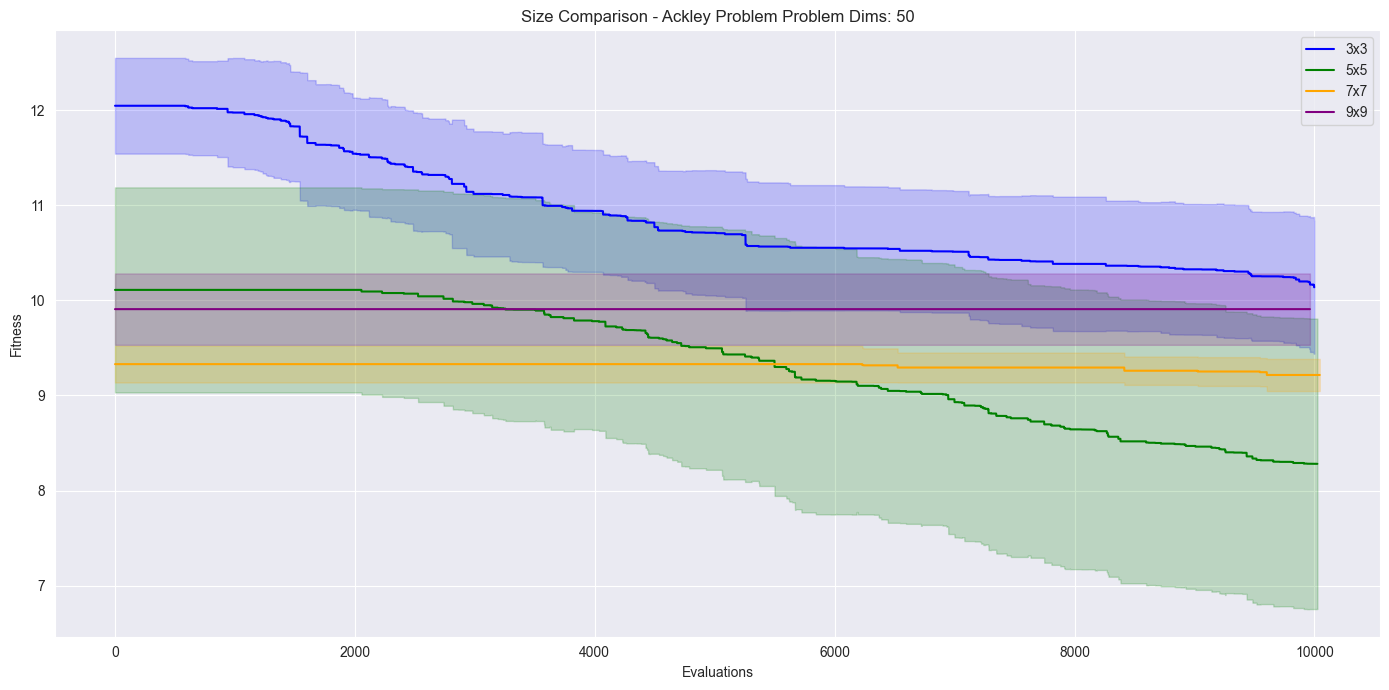

Running size comparison: Griewank Problem


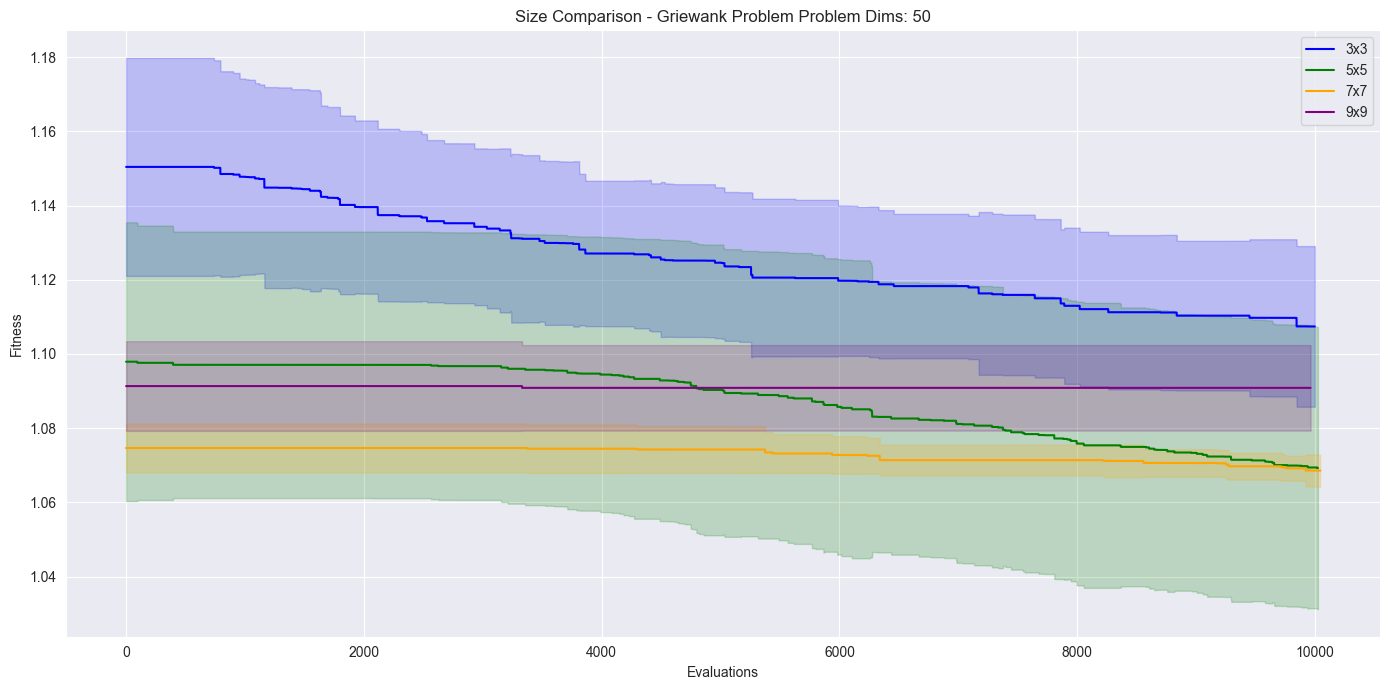

In [8]:
grid_configs = {
    (3, 3):"blue",
    (5, 5):"green",
    (7, 7):"orange",
    (9, 9):"purple"
}


run_size_comparison(problem_classes, grid_configs, graph_type="torus", dims=50, max_evals=10000, repetitions=5, show_std=True)

Running method comparison: Rastrigin Problem


2025-06-07 18:28:29,331 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|333/333, best_cost=-1.12e+5
2025-06-07 18:28:30,078 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -111865.73891859726, best pos: [-0.01835904  1.8927954   2.42569956 -1.90330723  1.86155426  0.86706319
 -0.26859313  1.20598847  0.86973959 -0.13010904  0.7851188  -0.49982621
  0.68676657  1.71836444  1.67566809 -2.08648102  0.69860509  1.84352605
  1.8779482   0.93922948  0.94587584 -0.01638621  1.73578123  1.95083508
  0.80214662 -2.07322386  0.70610261  0.88831261  1.88470907  0.7407469
 -1.19852681  0.90352547 -0.08130183  2.84174082  1.01448529  1.44118002
  1.75611912 -1.25288165  2.97437566  0.95532988  0.92381144  2.99617367
 -1.37172657 -1.11418062  0.87096629  0.02357275 -1.90708287  1.83251224
 -1.92749458  1.03322527]
2025-06-07 18:28:30,092 - pyswarms.single.global_best - INFO - Op

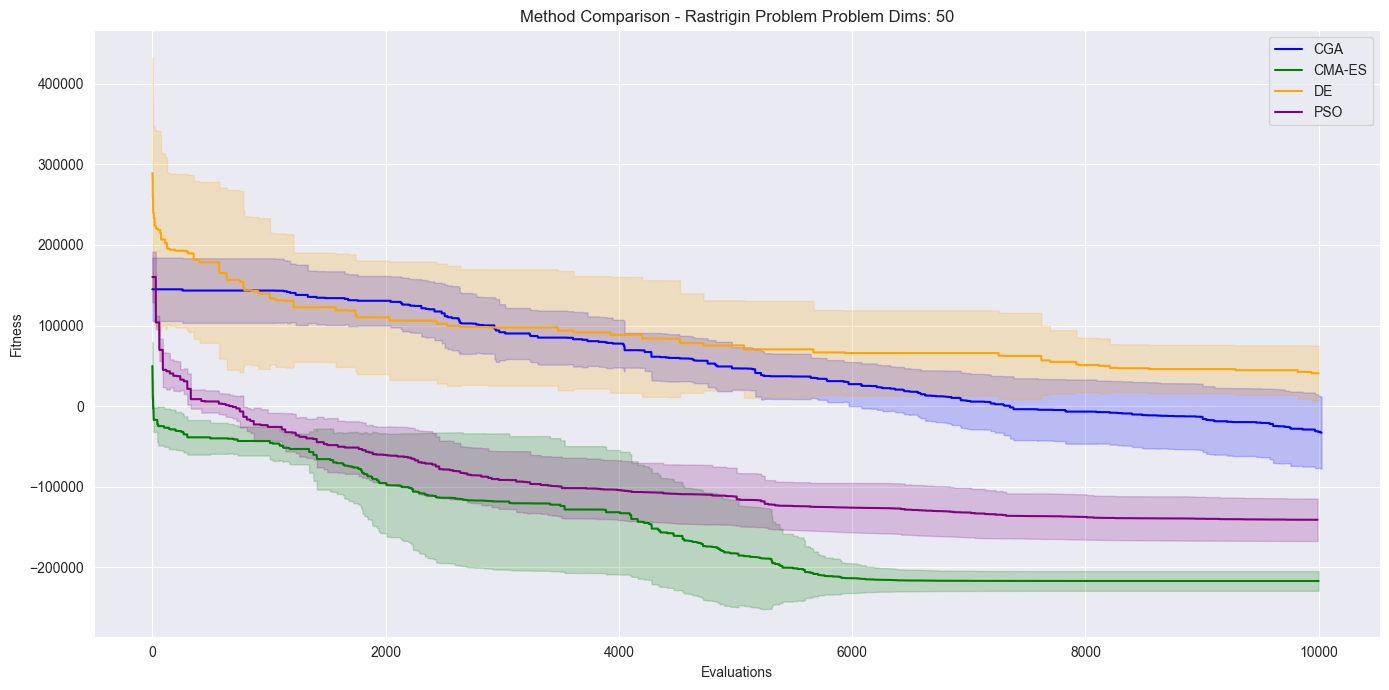

Running method comparison: Rosenbrock Problem


2025-06-07 18:34:32,585 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|333/333, best_cost=2.02e+3
2025-06-07 18:34:38,741 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 2024.0727771850577, best pos: [ 1.37997206  1.30396317  1.53542534  1.53052913  1.39843453  1.11120381
  0.86199043  1.12485541  0.82096227  0.55726738  2.05805694  1.35927227
  0.44953495  1.19977285  0.27879799  1.92042715  1.93698402  1.72537939
  0.56191915  1.28831624  1.20572669  0.02377156  1.24087297 -0.19351308
  1.77304847  1.12893508  1.2723473   2.27613756  1.41452987  0.85824047
  1.79755238  1.84980585  1.90062187  1.93020648  2.0445253   2.17293126
  1.37565526  0.03797739  0.60949838  1.39626852  0.95877967  0.78587057
  0.73033586  1.49593948  0.9670767   0.8049838   1.08718344 -0.62545421
  2.6355926   3.7168861 ]
2025-06-07 18:34:38,765 - pyswarms.single.global_best - INFO - Opt

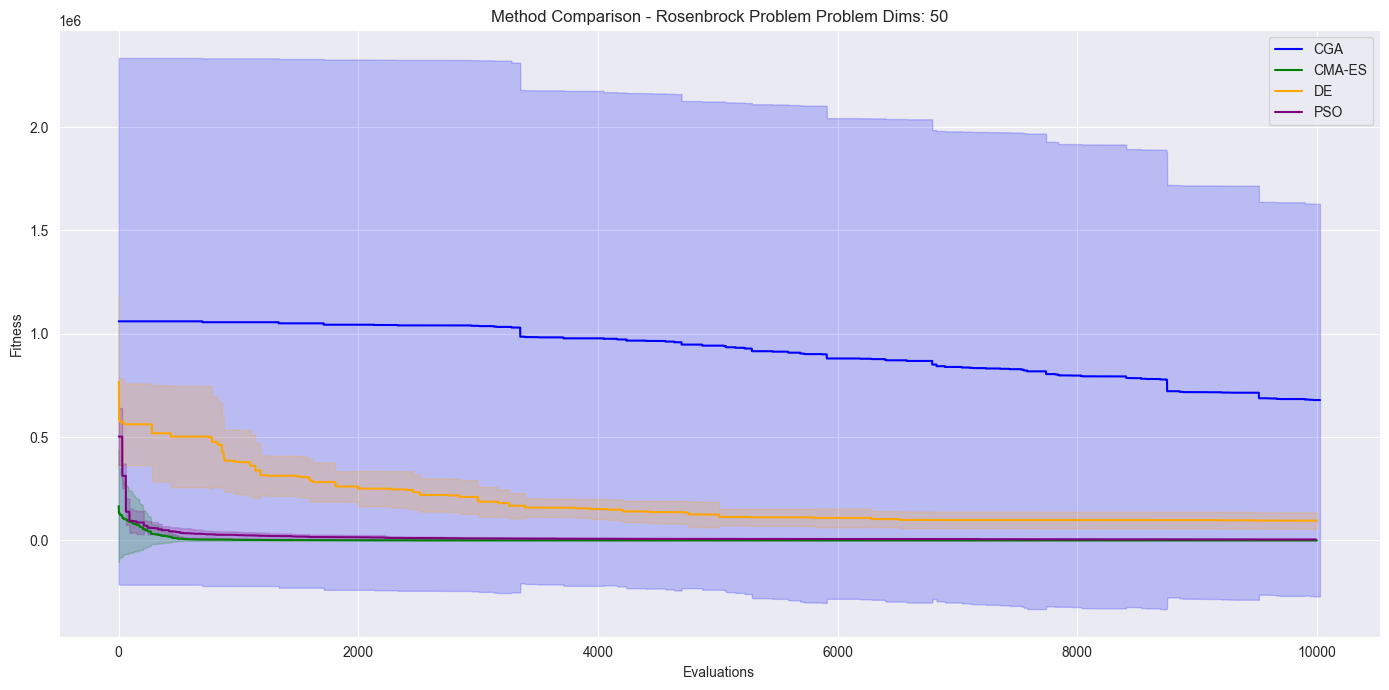

Running method comparison: Ackley Problem


2025-06-07 18:39:33,721 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|333/333, best_cost=4.03
2025-06-07 18:39:36,170 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 4.026519081286036, best pos: [-0.5840408   2.4212622   1.54471157  1.60752484  0.55795385  1.81190923
  1.59600431  1.57152772  1.43116558  2.13349582  1.461195    0.18457221
  1.39657966 -0.30568083  1.57245052  1.34288734  0.30621369  1.25040257
  1.09378291  1.6481651   0.44638869  1.53023589  1.66093551  1.97244266
  1.69525719  1.76470868  1.56992766  1.64152531  1.50119073  2.36544538
  1.62586379  0.53639657  1.49679107  1.57821302  1.5827971   0.7878763
  0.44507048  2.50799706  1.87875769  2.58719271  0.56667425  1.5016546
  2.08188418  2.50088822 -0.4360206   2.37171392 -0.40930066  0.6651474
  1.5284139   1.03379537]
2025-06-07 18:39:36,190 - pyswarms.single.global_best - INFO - Optimize f

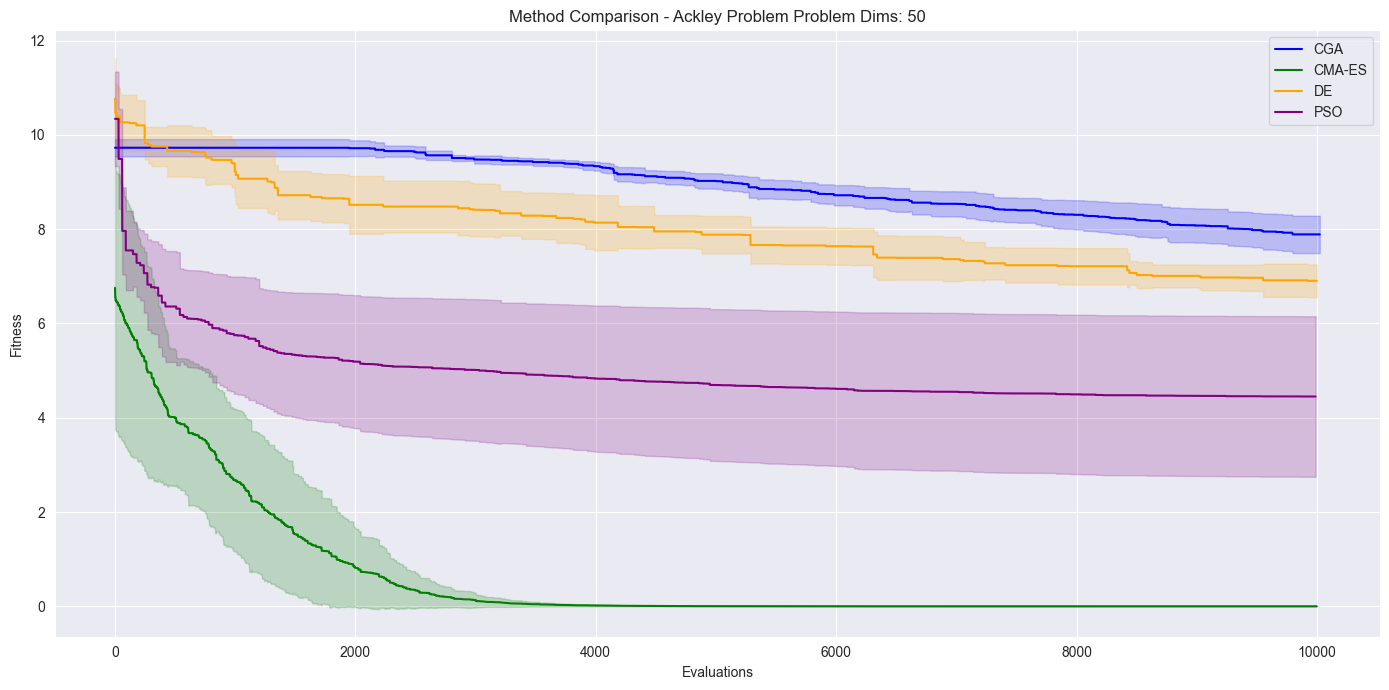

Running method comparison: Griewank Problem


2025-06-07 18:41:42,259 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


Failed for method DE: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.


pyswarms.single.global_best: 100%|██████████|333/333, best_cost=0.237
2025-06-07 18:41:43,185 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.23749195456124772, best pos: [ 0.69040541  0.62517851  0.74379571  0.67430918  0.67728922  0.67024754
  0.63939363  0.66783875 -0.34785659  0.45250625  0.67804938  0.73403414
  0.72510307  0.64954256  1.17816566  0.71425046  0.32673622  1.1198797
  0.82288493  0.64999012  0.72704242  0.72725649  2.04360125  1.40868423
  1.5529897   0.17857068  1.6154604   1.12558831  0.72529053  0.82301223
  0.7016203  -0.13093966  0.62257582  0.37348965  1.63354788  0.95292529
  2.14113485  0.62622676 -0.20219888  1.04790527  0.69514493  0.62658109
  0.99455903  1.85079959  0.70228466  1.24022156  1.37263446  0.3329897
  0.76176464  0.72083332]
2025-06-07 18:41:43,196 - pyswarms.single.global_best - INFO - Optimize for 333 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|333/333, best_cost=0.056

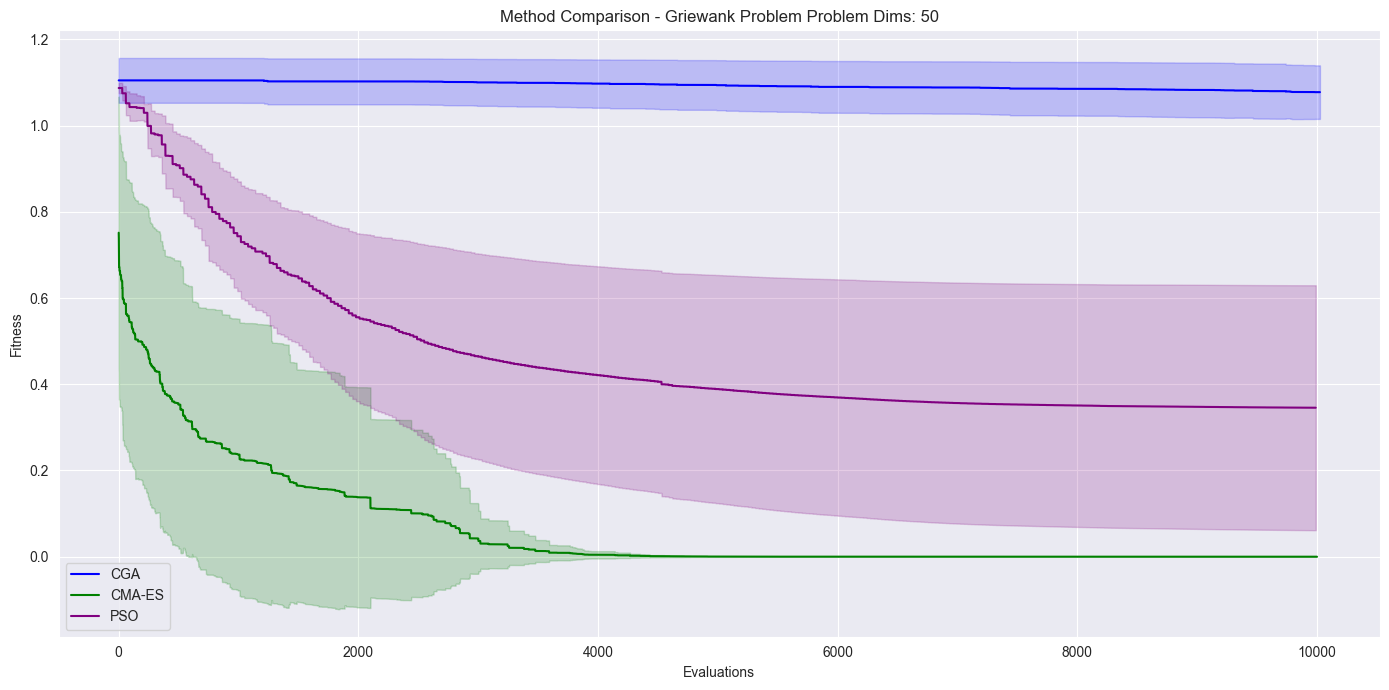

In [9]:
methods = {
    "CGA": (run_cga, "blue"),
    "CMA-ES": (run_cma, "green"),
    "DE": (run_differential_evolution, "orange"),
    "PSO": (run_pso, "purple")
}


run_method_comparison(problem_classes, methods, graph_type="torus", dims=50, max_evals=10000, repetitions=5, show_std=True)

Running: Rastrigin


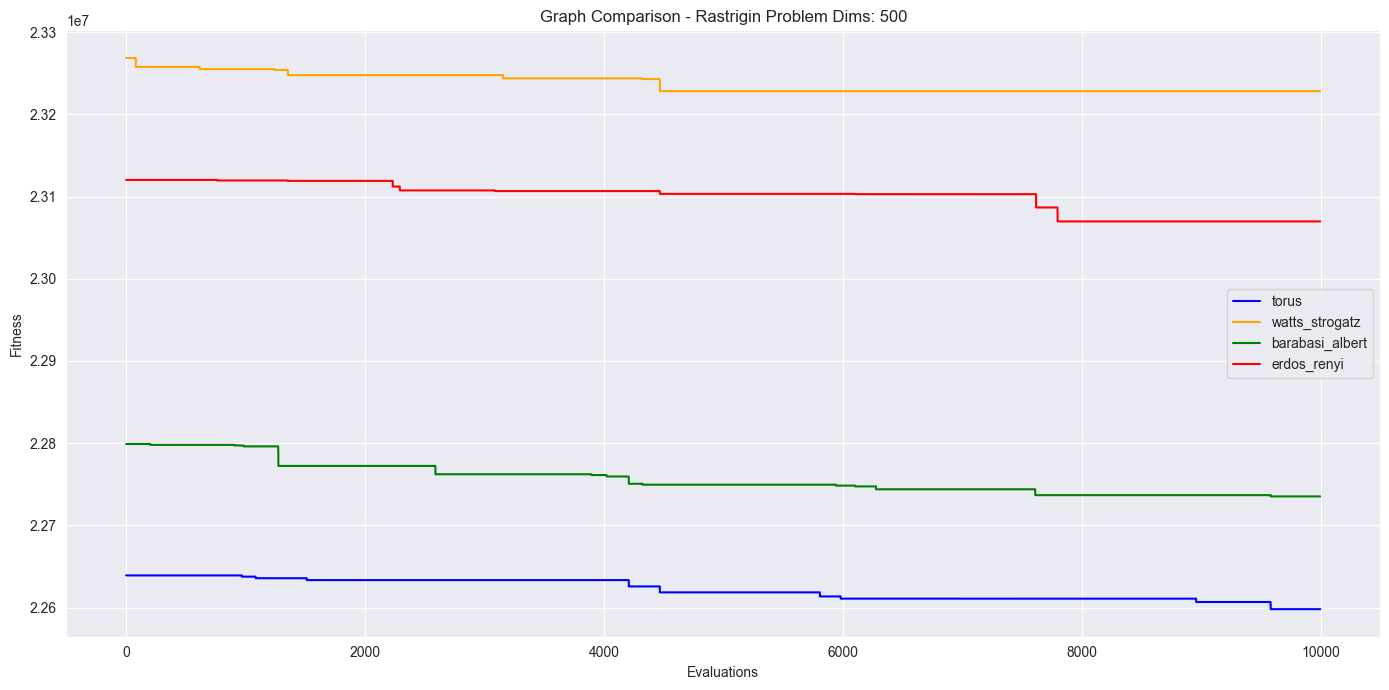

Running: Rosenbrock


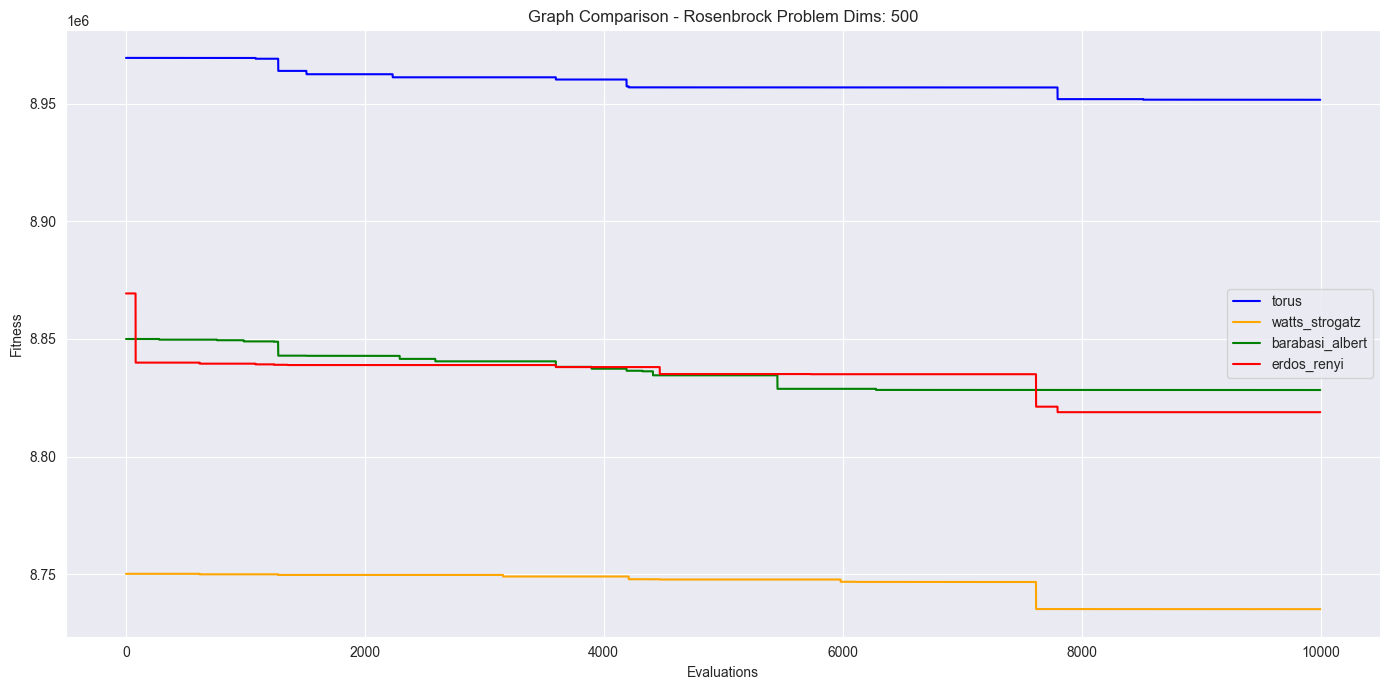

Running: Ackley


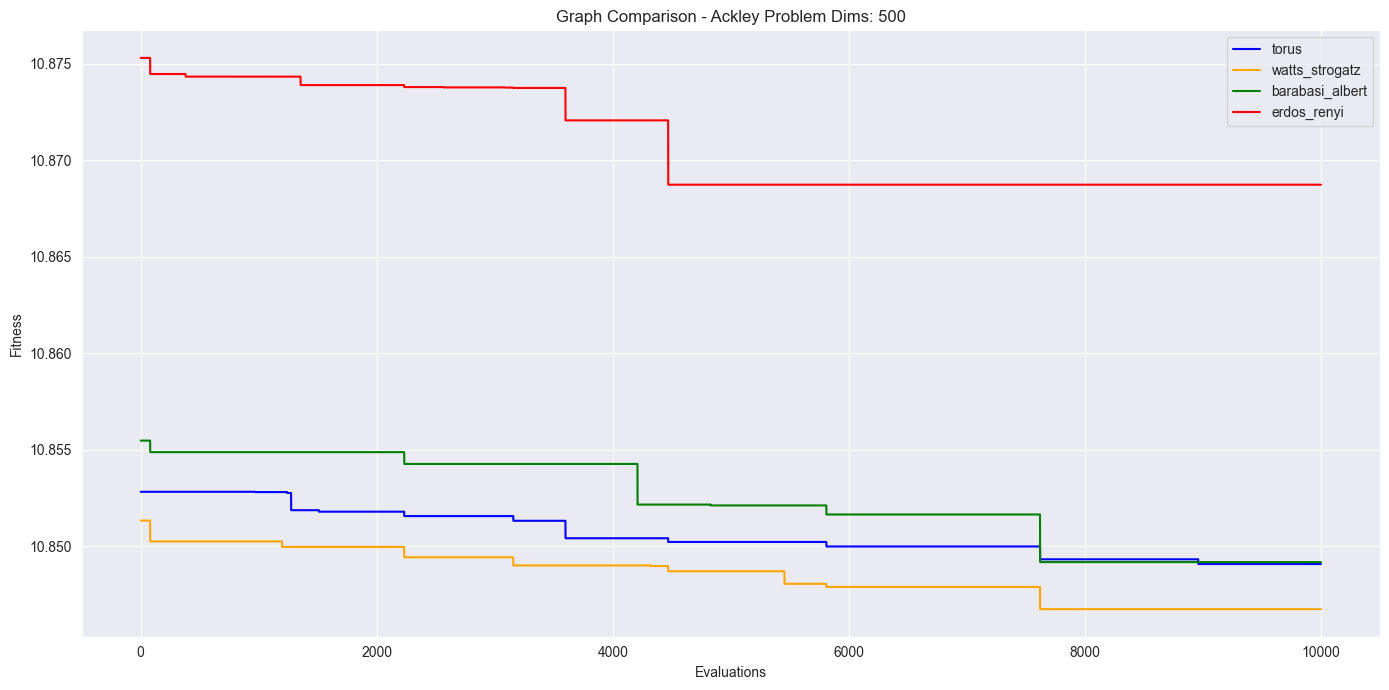

Running: Griewank


C:\Users\jakub\Desktop\Projects\UMISI\Sem_1\pycellga\pycellga\GraphProblem.py:113: RuntimeWarning: overflow encountered in scalar add
  sum_sq = sum(xi**2 for xi in x)


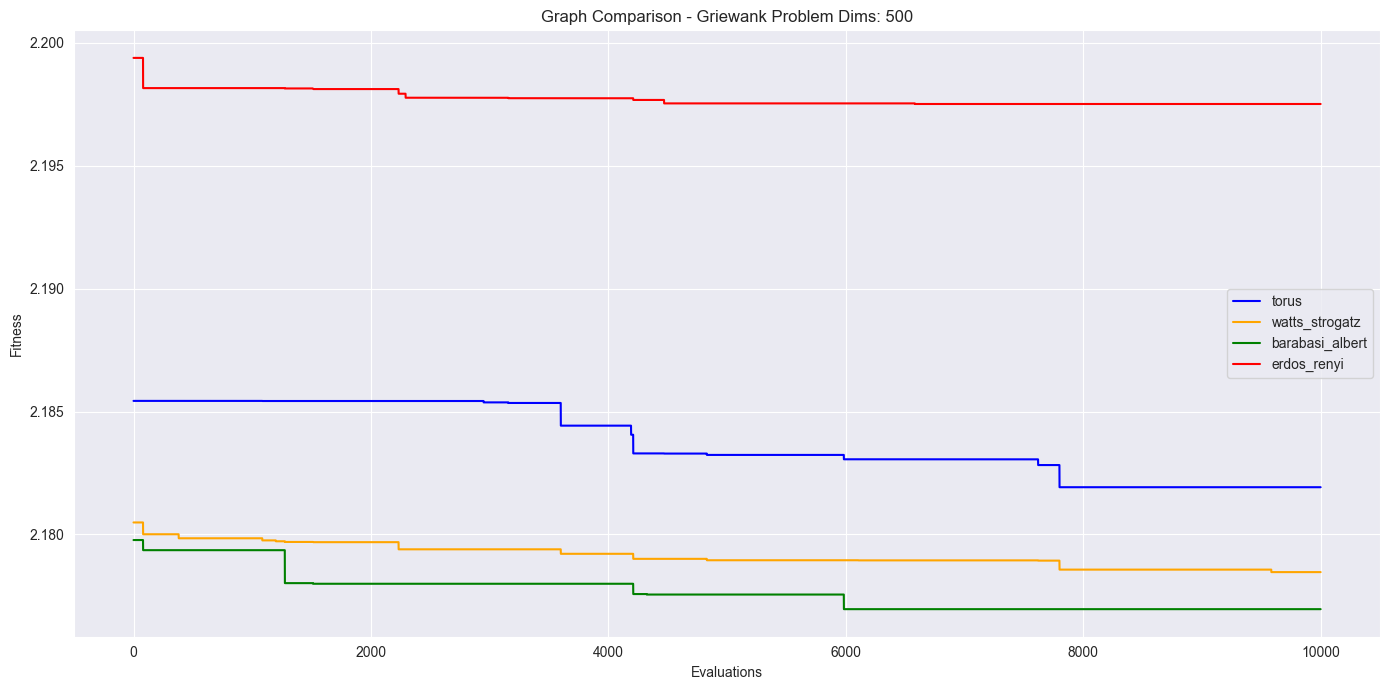

In [18]:
run_graph_comparison(problem_classes, graph_types, graphs_params, dims=500, max_evals=10000, repetitions=5, show_std=False, **config)